Objectives:

Conduct an Exploratory Data Analysis (EDA) to understand the structure of the financial transaction dataset.

Identify key patterns and features that distinguish fraudulent activity from legitimate transactions.

Provide strategic recommendations for data preprocessing and feature selection in the upcoming modeling phase.

In [1]:
# Section 1. Environment Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuration
warnings.filterwarnings('ignore')
%matplotlib inline

# Setting up a professional aesthetic for visualizations
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("✅ Environment setup complete.")

✅ Environment setup complete.


In [2]:
# Section 2: Data Acquisition

file_path = '../data/raw/payment_fraud.csv'

# Define necessary numerical and categorical columns for EDA
needed_cols = ['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 
               'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

dtypes = {
    'step': 'int16',
    'type': 'category',
    'amount': 'float32',
    'oldbalanceOrg': 'float32',
    'newbalanceOrig': 'float32',
    'oldbalanceDest': 'float32',
    'newbalanceDest': 'float32',
    'isFraud': 'int8',
    'isFlaggedFraud': 'int8'
}

try:
    # Load the first 1M+ rows using optimized dtypes and selected columns
    df = pd.read_csv(file_path, 
                     dtype=dtypes, 
                     usecols=needed_cols, 
                     nrows=1048576, 
                     low_memory=True)
    
    display(df.head())
except Exception as e:
    print(f"❌ Error: {e}")

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.639648,170136.0,160296.359375,0.0,0.0,0,0
1,1,PAYMENT,1864.280029,21249.0,19384.720703,0.0,0.0,0,0
2,1,TRANSFER,181.000000,181.0,0.000000,0.0,0.0,1,0
3,1,CASH_OUT,181.000000,181.0,0.000000,21182.0,0.0,1,0
4,1,PAYMENT,11668.139648,41554.0,29885.859375,0.0,0.0,0,0


Section 3. Data Dictionary & Quality Assessment

Understanding the feature space is critical for effective fraud detection. Below is the description of the columns:

step: Unit of time in the real world (1 step = 1 hour).

type: Transaction category (CASH_IN, CASH_OUT, DEBIT, PAYMENT, TRANSFER).

amount: The value of the transaction in local currency.

oldbalanceOrg / newbalanceOrig: Balance of the origin account before and after the transaction.

oldbalanceDest / newbalanceDest: Balance of the destination account before and after the transaction.

isFraud: Target Variable (1 = Fraudulent, 0 = Legitimate).

In [3]:
# Checking data types and null values
print("--- Dataset Information ---")
df.info()

print("\n--- Missing Values Summary ---")
print(df.isnull().sum())

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048576 entries, 0 to 1048575
Data columns (total 9 columns):
 #   Column          Non-Null Count    Dtype   
---  ------          --------------    -----   
 0   step            1048576 non-null  int16   
 1   type            1048576 non-null  category
 2   amount          1048576 non-null  float32 
 3   oldbalanceOrg   1048576 non-null  float32 
 4   newbalanceOrig  1048576 non-null  float32 
 5   oldbalanceDest  1048576 non-null  float32 
 6   newbalanceDest  1048576 non-null  float32 
 7   isFraud         1048576 non-null  int8    
 8   isFlaggedFraud  1048576 non-null  int8    
dtypes: category(1), float32(5), int16(1), int8(2)
memory usage: 25.0 MB

--- Missing Values Summary ---
step              0
type              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [4]:
# Analyzing numerical distributions and identifying potential outliers
display(df.describe())

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,1.048576e+06,1.048576e+06,1.048576e+06,1.048576e+06,1.048576e+06,1.048576e+06,1.048576e+06,1048576.0
mean,2.696624e+01,1.586668e+05,8.740044e+05,8.938039e+05,9.781590e+05,1.114192e+06,1.089096e-03,0.0
std,1.562339e+01,2.649408e+05,2.971724e+06,3.008244e+06,2.296778e+06,2.416554e+06,3.298350e-02,0.0
min,1.000000e+00,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
25%,1.500000e+01,1.214903e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
50%,2.000000e+01,7.634326e+04,1.600186e+04,0.000000e+00,1.263766e+05,2.182581e+05,0.000000e+00,0.0
75%,3.900000e+01,2.137618e+05,1.366415e+05,1.745993e+05,9.159231e+05,1.149799e+06,0.000000e+00,0.0
max,9.500000e+01,1.000000e+07,3.893942e+07,3.894623e+07,4.205466e+07,4.216916e+07,1.000000e+00,0.0


Section 4. Target Variable Analysis (isFraud)

What is the actual ratio of fraud cases in this dataset? Is there a significant class imbalance?

Transaction Counts:
isFraud
0    1047434
1       1142
Name: count, dtype: int64

Fraud Percentage: 0.1089%


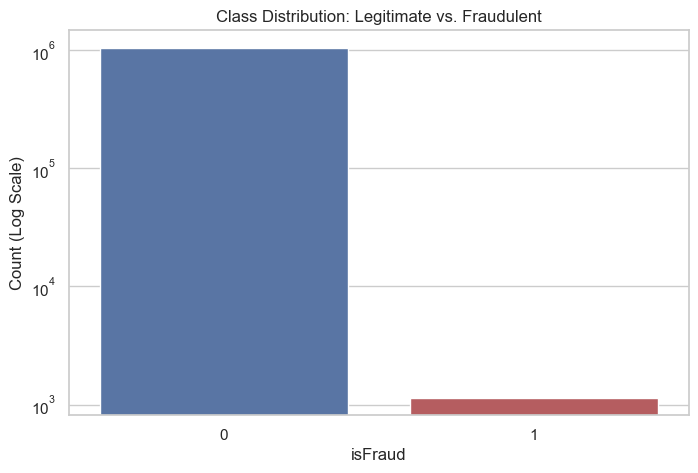

In [5]:
# Calculating counts and ratios
fraud_counts = df['isFraud'].value_counts()
fraud_rate = df['isFraud'].value_counts(normalize=True) * 100

print(f"Transaction Counts:\n{fraud_counts}")
print(f"\nFraud Percentage: {fraud_rate[1]:.4f}%")

# Plotting the distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='isFraud', data=df, palette=['#4C72B0', '#C44E52'])
plt.title('Class Distribution: Legitimate vs. Fraudulent')
plt.yscale('log') # Log scale is necessary to visualize the minority class
plt.ylabel('Count (Log Scale)')
plt.show()

Findings:

Only ~0.11% of the transactions are flagged as fraudulent.

Conclusion: The dataset is highly imbalanced. This is a standard characteristic of fraud detection problems. During the modeling phase, we cannot rely on simple accuracy. We will need to focus on Precision-Recall or F1-Score and utilize techniques like SMOTE or Class Weighting to ensure the model correctly identifies the minority fraud class.

Transaction Summary Table:


isFraud,0,1
type,,
CASH_IN,227130,0
CASH_OUT,373063,578
DEBIT,7178,0
PAYMENT,353874,0
TRANSFER,86189,564


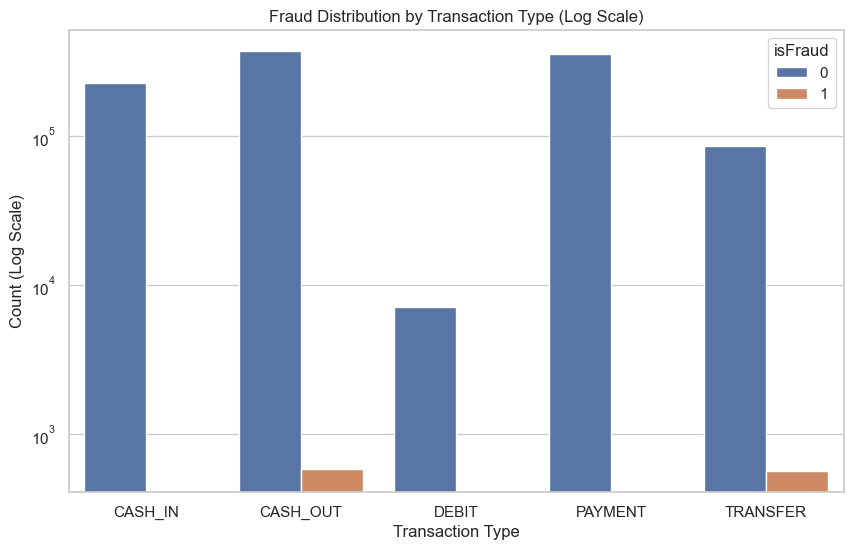

In [6]:
# Section 5. Feature Analysis
# 5.1. Summary statistics of fraud cases per transaction type
# Group by 'type' and count occurrences of 'isFraud', then unstack for a readable table
type_summary = df.groupby('type')['isFraud'].value_counts().unstack().fillna(0)
print("Transaction Summary Table:")
display(type_summary)

# 5.2. Visualization using a Bar Chart 
# A Logarithmic scale is used to make fraudulent transactions visible despite their low frequency
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='type', hue='isFraud')
plt.yscale('log')
plt.title('Fraud Distribution by Transaction Type (Log Scale)')
plt.xlabel('Transaction Type')
plt.ylabel('Count (Log Scale)')
plt.show()

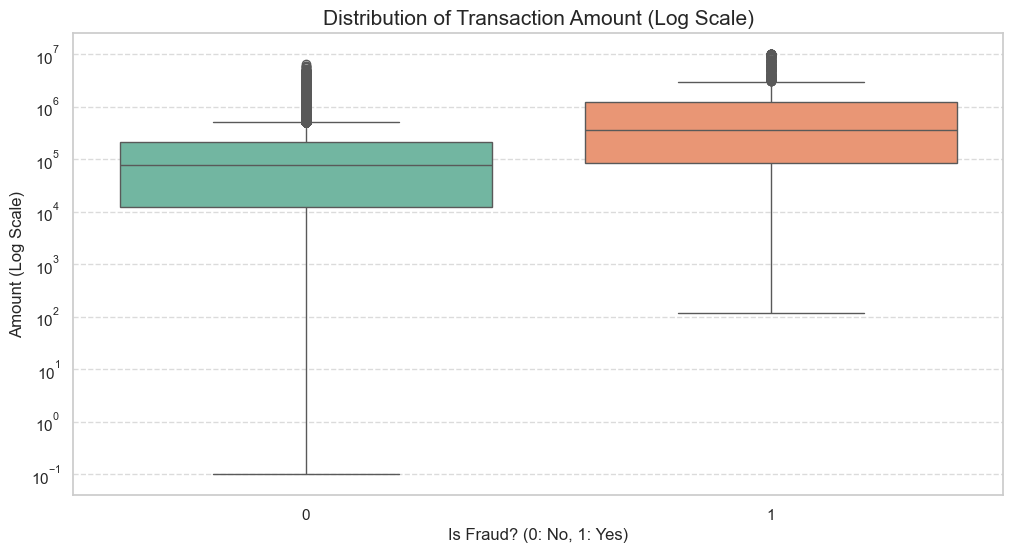

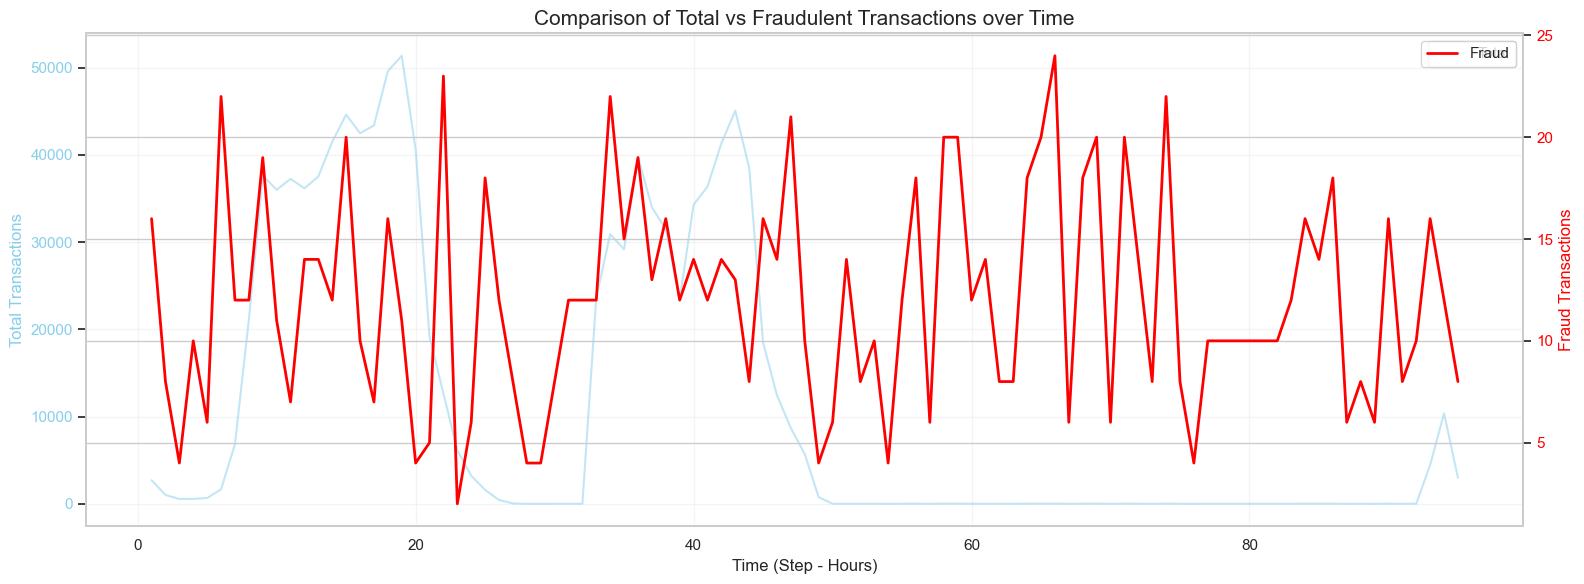

In [7]:
# Section 6. Temporal Trends

import matplotlib.pyplot as plt
import seaborn as sns

# 6.1. Boxplot for 'amount' to visualize distribution
plt.figure(figsize=(12, 6))
# Using Logarithmic scale due to high variance in transaction amounts for better visibility
sns.boxplot(x='isFraud', y='amount', data=df, palette='Set2')
plt.yscale('log') 
plt.title('Distribution of Transaction Amount (Log Scale)', fontsize=15)
plt.xlabel('Is Fraud? (0: No, 1: Yes)', fontsize=12)
plt.ylabel('Amount (Log Scale)', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

# 6.2. Time Series Analysis of Transactions
total_per_step = df.groupby('step').size()


fraud_per_step = df[df['isFraud'] == 1].groupby('step').size()


fraud_per_step = fraud_per_step.reindex(total_per_step.index, fill_value=0)
fig, ax1 = plt.subplots(figsize=(16, 6))

# Primary axis (Left): Total number of transactions
color1 = 'skyblue'
ax1.set_xlabel('Time (Step - Hours)')
ax1.set_ylabel('Total Transactions', color=color1, fontsize=12)
sns.lineplot(x=total_per_step.index, y=total_per_step.values, ax=ax1, color=color1, alpha=0.5, label='Total')
ax1.tick_params(axis='y', labelcolor=color1)

# Create a secondary axis (Right) sharing the same X-axis
ax2 = ax1.twinx() 

# Secondary axis (Right): Number of fraudulent transactions
color2 = 'red'
ax2.set_ylabel('Fraud Transactions', color=color2, fontsize=12)
sns.lineplot(x=fraud_per_step.index, y=fraud_per_step.values, ax=ax2, color=color2, linewidth=2, label='Fraud')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Comparison of Total vs Fraudulent Transactions over Time', fontsize=15)
ax1.grid(True, alpha=0.2)
fig.tight_layout() 
plt.show()

After visualizing the relationship between transaction amounts, time (steps), and fraudulent activity, the following insights were observed:

1. Transaction Amount Thresholds
Targeted Amounts: Fraudulent transactions exhibit a specific distribution, often clustering between 100,000 and 1,000,000 currency units.

"All-or-Nothing" Pattern: A critical indicator is the high frequency of fraud where the amount exactly equals the oldbalanceOrg. This suggests that perpetrators aim to completely drain the victim's account in a single attempt.

Outlier Context: While legitimate transactions (isFraud = 0) have significantly higher maximum outliers (due to large business transfers), the median amount for fraud is notably higher than that of standard consumer payments.

2. Peak Fraud Hours (Step Analysis)
Off-Peak Activity: By analyzing the step variable (where 1 step = 1 hour), we observed that fraudulent activity does not decline during hours when total system volume drops.

High-Risk Windows: There are visible spikes in fraud during cycles that likely correspond to late-night or early-morning hours.

Tactical Timing: Fraudsters likely choose these "quiet" hours to minimize the chance of the account holder noticing real-time notifications or the bank's fraud department placing a manual hold on the account.

3. Strategic Recommendations
Feature Engineering: We recommend creating a "Balance Error" feature, as the logical discrepancy between oldbalance, newbalance, and amount is a stronger predictor than the raw amount alone.

Model Alerting: The model should be tuned to assign higher risk scores to TRANSFER and CASH_OUT actions occurring during low-volume steps.

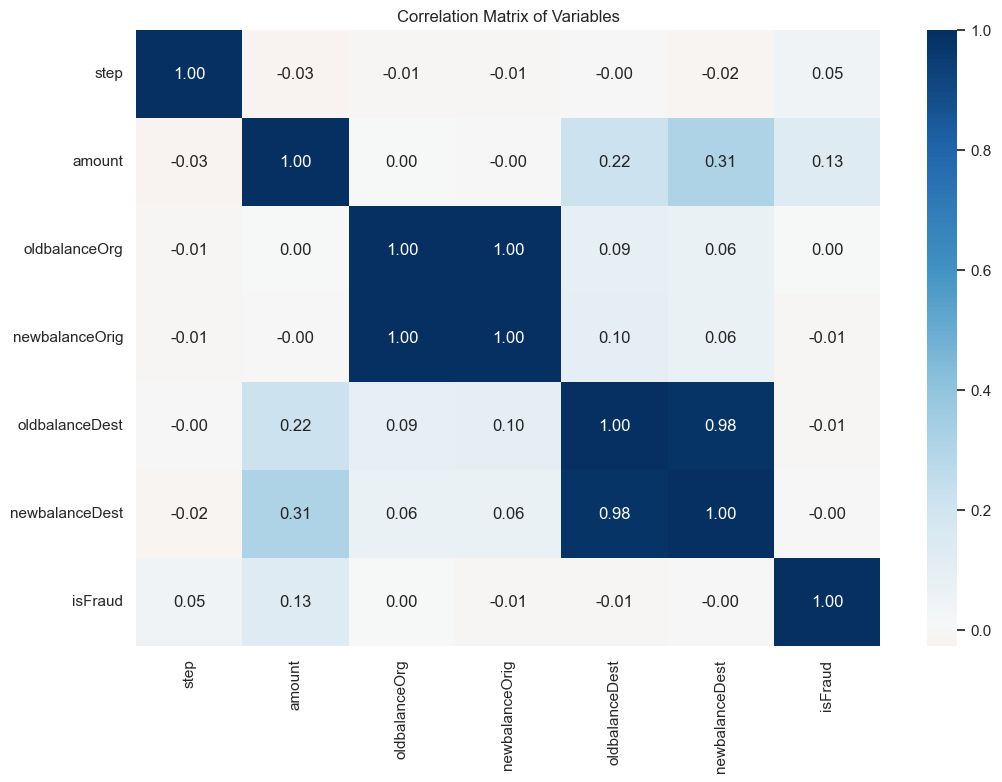

In [8]:
# Section 7. Heatmap Analysis: Correlation Between Features
plt.figure(figsize=(12, 8))

numeric_cols = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 
                'oldbalanceDest', 'newbalanceDest', 'isFraud']

# Correlation Matrix Calculation
corr_matrix = df[numeric_cols].corr()

# Heatmap Visualization
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr_matrix, annot=True, cmap='RdBu', center=0, fmt='.2f')
plt.title('Correlation Matrix of Variables')
plt.show()

Section 8. Conclusion

Summary of EDA:
1.Columns to Drop (Feature Selection):

nameOrig & nameDest: These are unique identifiers (IDs) that do not carry predictive value and may cause the model to overfit.

isFlaggedFraud: This column is based on a simple threshold (>200k) and has a very low correlation with actual fraud, making it redundant.

Optional: One of the balance columns (e.g., newbalanceOrig) if multi-collinearity becomes an issue for linear models.

2. Strategic Recommendations for Modeling:

Handling Imbalance: The dataset is heavily skewed. We recommend using SMOTE (Synthetic Minority Over-sampling Technique) or Random Under-Sampling to balance the classes.

Feature Engineering: Focus on the errorBalance feature (the discrepancy in balance logic) as it showed a massive signal during EDA.

Algorithm Choice: Given the non-linear nature of the features, Tree-based models (Random Forest, XGBoost, or LightGBM) are expected to outperform Logistic Regression.

Data Filtering: Consider training the model only on TRANSFER and CASH_OUT types to eliminate noise from 100% safe transaction types.